# Pupil Detection Feature Zoo

This notebook compares classical image features and pupil-detection approaches on an eye image.

Inputs:
- `IMAGE_PATH` = eye image
- `MASK_PATH` = ignore mask (255 = valid, 0 = ignore)

The mask is applied consistently across all detectors.


In [61]:
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

#root = tk.Tk()
#root.withdraw()

"""IMAGE_PATH = filedialog.askopenfilename(
    title="Select eye image",
    initialdir=str(Path.cwd()),
    filetypes=[
        ("Image files", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff"),
        ("All files", "*.*")
    ]
)"""

IMAGE_PATH = "Transfers/capture_20260531_141626/ambient.jpg"
#root.destroy()

if not IMAGE_PATH:
    raise RuntimeError("No image selected")

MASK_PATH = "calibration/led_cover_mask.png"


In [62]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.feature import canny, local_binary_pattern, corner_harris, corner_peaks
from skimage.filters import sobel, laplace, gabor

plt.rcParams["figure.figsize"] = (8,6)


(1280, 960)
uint8


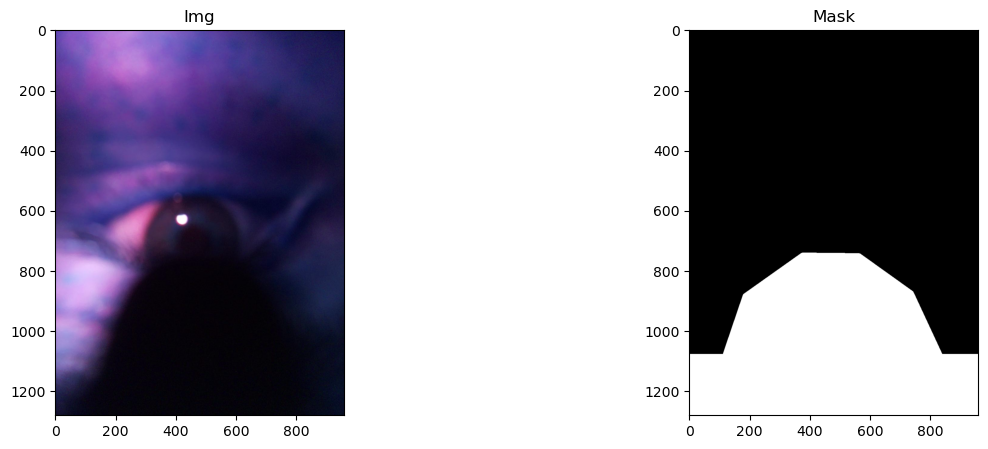

In [63]:
img = cv2.imread(IMAGE_PATH)
img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
mask = cv2.imread(MASK_PATH)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
print(mask.shape)
print(mask.dtype)

fig1, ax1 = plt.subplots(1,2, figsize=(15,5))
ax1[0].imshow(img, cmap="gray"); ax1[0].set_title("Img")
ax1[1].imshow(mask, cmap="gray"); ax1[1].set_title("Mask")
#ax[2].imshow(lap, cmap="gray"); ax[2].set_title("Laplacian")
plt.show()
if img is None:
    raise FileNotFoundError(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
if mask is None:
    raise FileNotFoundError(MASK_PATH)








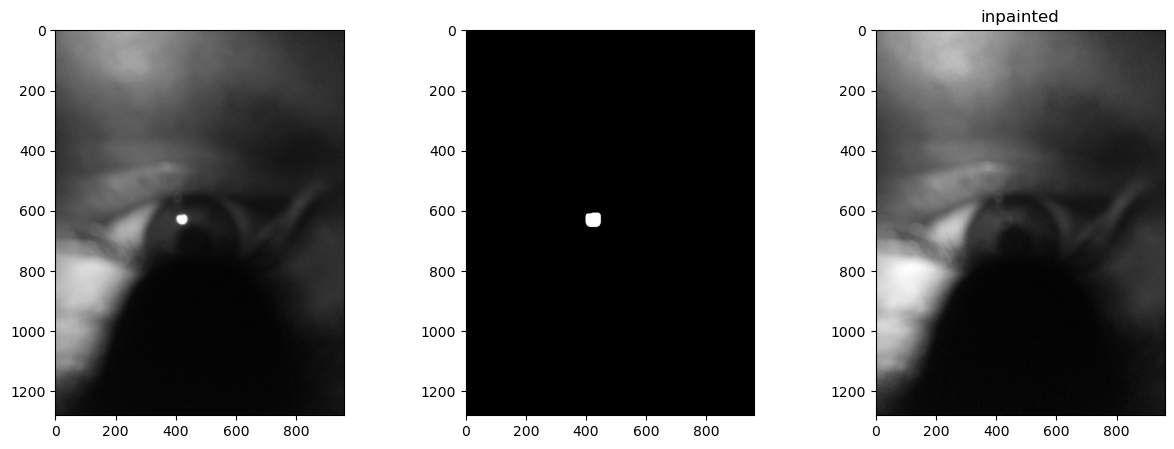

In [64]:
threshold = 3 * 255 - 50

cornealmask = np.where(img.sum(axis=2) > threshold, 255, 0).astype(np.uint8)
kernel = np.ones((10,10), np.uint8)
cornealmask = cv2.dilate(cornealmask, kernel, iterations=2)


initgray = gray.copy()
gray = cv2.inpaint(initgray, cornealmask, 15, cv2.INPAINT_TELEA)

fig2, ax2 = plt.subplots(1,3, figsize=(15,5))
ax2[0].imshow(initgray, cmap="gray"); ax1[0].set_title("Img")
ax2[1].imshow(cornealmask, cmap="gray"); ax1[1].set_title("Mask")
ax2[2].imshow(gray, cmap="gray"); ax2[2].set_title("inpainted")
plt.show()

In [65]:

# Load the ma

# Inpaint.

#gray = cv2.inpaint(gray, cornealmask, 3, cv2.INPAINT_NS)
#cv2.imshow("inpainted",gray)
#plt.show()

(1280, 960)
bool
Loaded: (1280, 960)


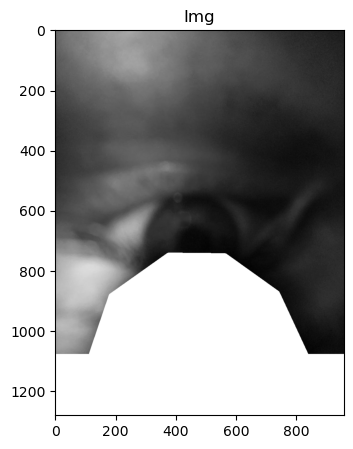

In [ ]:
valid = mask < 255

gray_masked = gray.copy()
print(valid.shape)
print(valid.dtype)
gray_masked[~valid] = 255

#cv2.imshow("gray_masked" , gray_masked)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
proc = clahe.apply(gray)

print("Loaded:", proc.shape)

cv2.imwrite("proc.png", proc )
fig3, ax3 = plt.subplots(1,1, figsize=(15,5))
ax3.imshow(gray_masked, cmap="gray"); ax3.set_title("Img")

plt.show()

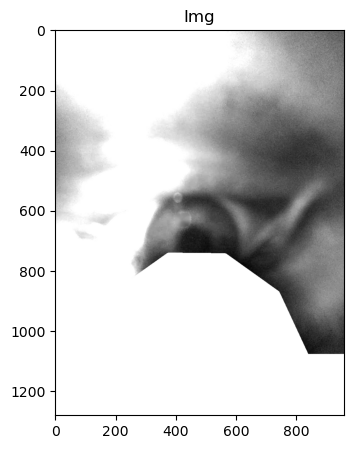

In [67]:
contrast = 3   # >1 increases contrast, <1 decreases
brightness = 0.8   # shift intensity

adjusted = cv2.convertScaleAbs(gray_masked, alpha=contrast, beta=brightness)
proc = adjusted


fig3, ax3 = plt.subplots(1,1, figsize=(15,5))
ax3.imshow(proc, cmap="gray"); ax3.set_title("Img")

plt.show()

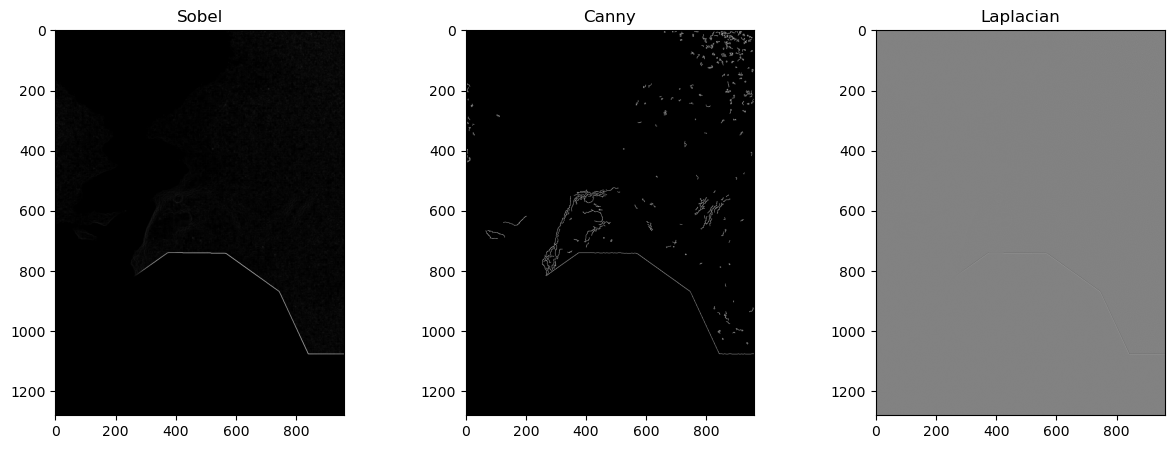

In [68]:
sob = sobel(proc)
can = canny(proc)
lap = laplace(proc)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(sob, cmap="gray"); ax[0].set_title("Sobel")
ax[1].imshow(can, cmap="gray"); ax[1].set_title("Canny")
ax[2].imshow(lap, cmap="gray"); ax[2].set_title("Laplacian")
plt.show()





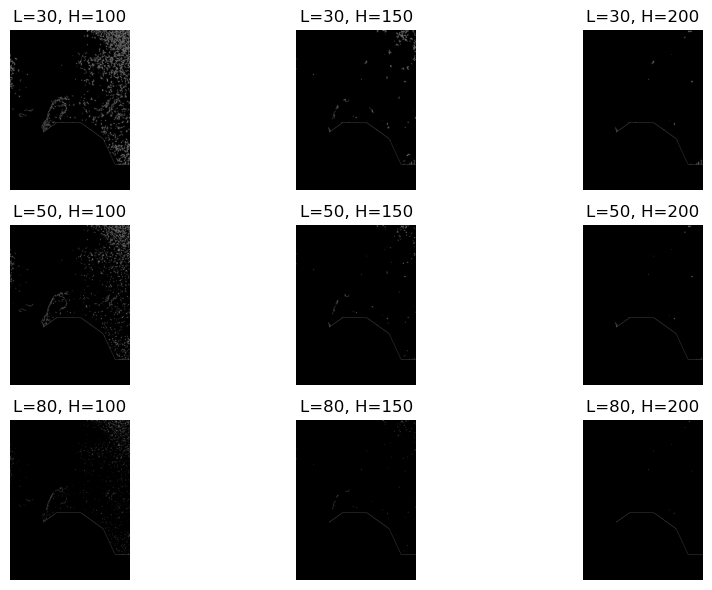

In [69]:


low_vals = [30, 50, 80]
high_vals = [100, 150, 200]

fig, axes = plt.subplots(len(low_vals), len(high_vals), figsize=(10, 6))

for i, low in enumerate(low_vals):
    for j, high in enumerate(high_vals):

        edges = cv2.Canny(proc, low, high)

        ax = axes[i, j]
        ax.imshow(edges, cmap='gray')
        ax.set_title(f"L={low}, H={high}")
        ax.axis("off")

plt.tight_layout()
plt.show()

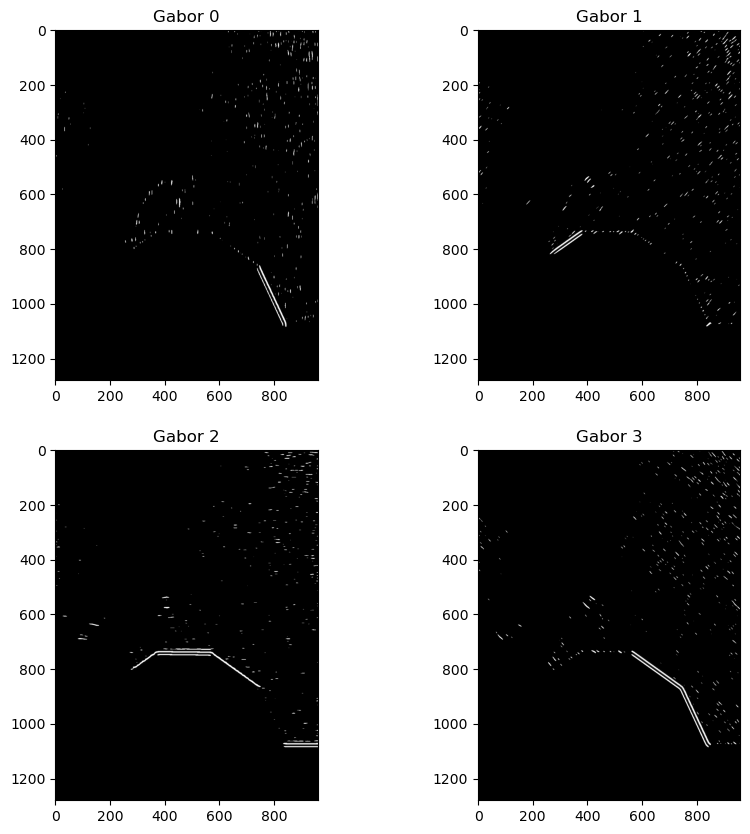

In [70]:
gabor_responses = []

for theta in np.arange(0, np.pi, np.pi/4):
    real, imag = gabor(proc, frequency=0.1, theta=theta)
    gabor_responses.append(real)

fig, ax = plt.subplots(2,2, figsize=(10,10))
for a, r, t in zip(ax.ravel(), gabor_responses, range(4)):
    a.imshow(r, cmap="gray")
    a.set_title(f"Gabor {t}")
plt.show()


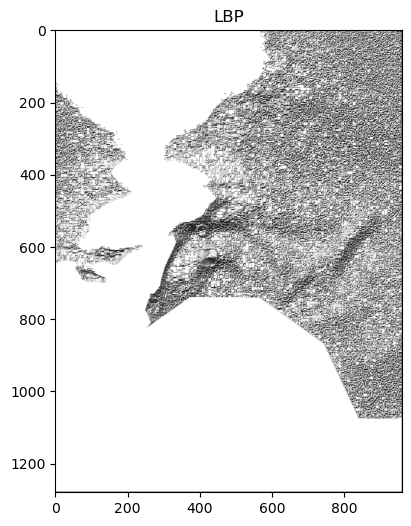

In [71]:
lbp = local_binary_pattern(proc, P=8, R=1)

plt.imshow(lbp, cmap="gray")
plt.title("LBP")
plt.show()


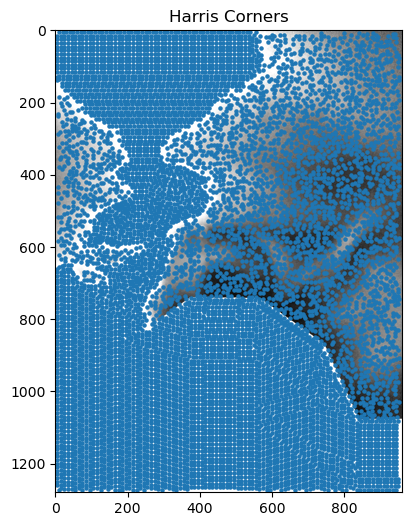

In [72]:
harris = corner_harris(proc)
corners = corner_peaks(harris, min_distance=5)

plt.imshow(proc, cmap="gray")
plt.scatter(corners[:,1], corners[:,0], s=5)
plt.title("Harris Corners")
plt.show()


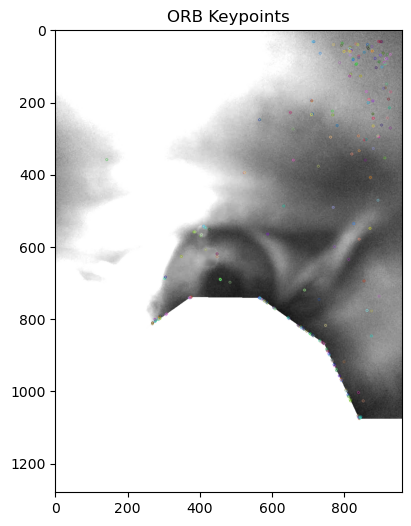

In [73]:
orb = cv2.ORB_create(nfeatures=500)
kps = orb.detect(proc, None)

orb_img = cv2.drawKeypoints(proc, kps, None)

plt.imshow(cv2.cvtColor(orb_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.show()


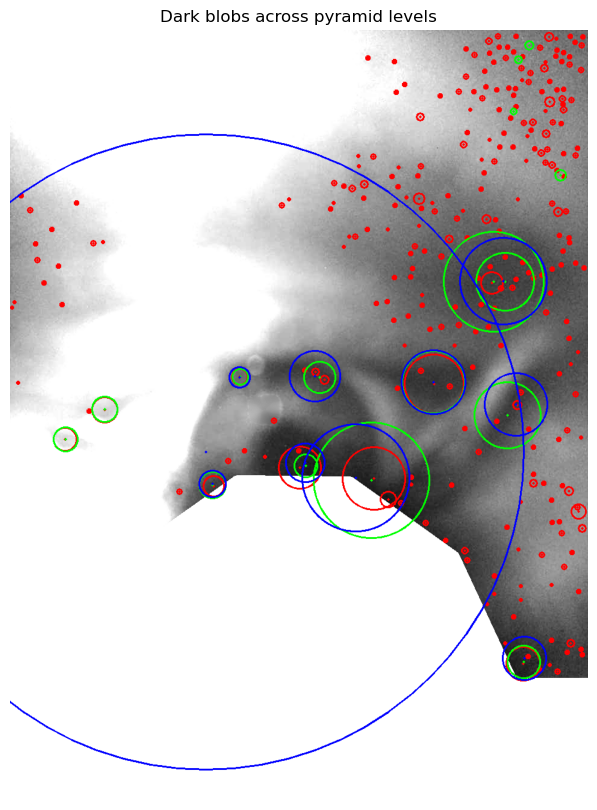

In [74]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()
params.filterByColor = True
params.blobColor = 0  # dark blobs

params.filterByArea = True
params.minArea = 20
params.maxArea = 100000


params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

params.minThreshold = 0
params.maxThreshold = 255
params.thresholdStep = 5



detector = cv2.SimpleBlobDetector_create(params)

# Pyramid


levels = [proc]
for _ in range(2):
    levels.append(cv2.pyrDown(levels[-1]))

# Display image
overlay = cv2.cvtColor(proc, cv2.COLOR_GRAY2RGB)

colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for level_idx, (img_lvl, color) in enumerate(zip(levels, colors)):
    keypoints = detector.detect(img_lvl)

    scale = 2 ** level_idx

    for kp in keypoints:
        x = int(kp.pt[0] * scale)
        y = int(kp.pt[1] * scale)
        r = int(kp.size * scale / 2)

        cv2.circle(overlay, (x, y), r, color, 2)
        cv2.circle(overlay, (x, y), 2, color, -1)

plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.title("Dark blobs across pyramid levels")
plt.axis("off")
plt.show()

proc = adjusted

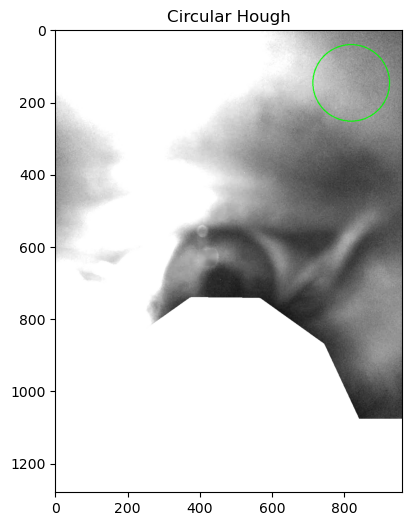

In [75]:
circles = cv2.HoughCircles(
    proc,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=20,
    minRadius=15,
    maxRadius=120
)

circle_result = cv2.cvtColor(proc, cv2.COLOR_GRAY2BGR)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0,:1]:
        cv2.circle(circle_result, (c[0],c[1]), c[2], (0,255,0), 2)

plt.imshow(cv2.cvtColor(circle_result, cv2.COLOR_BGR2RGB))
plt.title("Circular Hough")
plt.show()


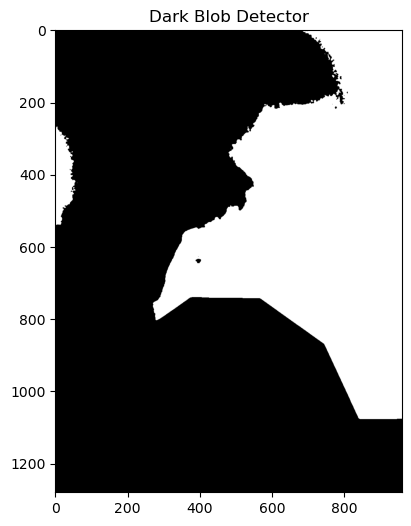

Blob center: [734.10910254 530.43016275]


In [76]:
blur = cv2.GaussianBlur(proc,(9,9),0)

_, th = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

#th[~valid] = 0

num, labels, stats, centroids = cv2.connectedComponentsWithStats(th)

largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA]) if num > 1 else None

blob_center = None

if largest is not None:
    blob_center = centroids[largest]

plt.imshow(th, cmap="gray")
plt.title("Dark Blob Detector")
plt.show()

print("Blob center:", blob_center)


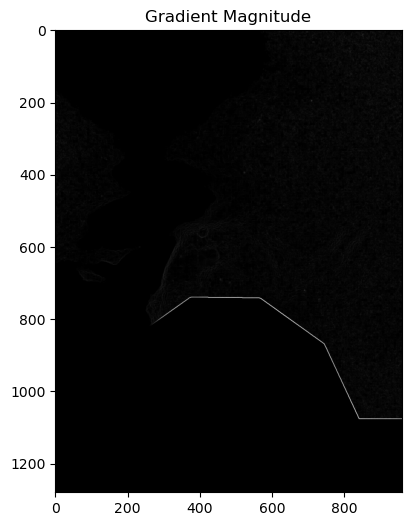

In [77]:
gx = cv2.Sobel(proc, cv2.CV_32F, 1, 0)
gy = cv2.Sobel(proc, cv2.CV_32F, 0, 1)

mag = np.sqrt(gx**2 + gy**2)

plt.imshow(mag, cmap="gray")
plt.title("Gradient Magnitude")
plt.show()


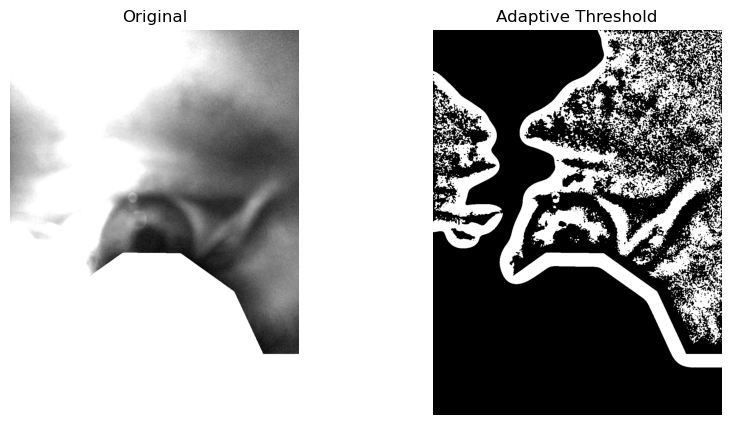

In [87]:

# optional: mild smoothing helps stability
blur = cv2.GaussianBlur(proc, (5,5), 0)

# adaptive threshold
th = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
   107,   # block size (must be odd)
    0    # C constant (tuning knob)
)

# show
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(proc, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(th, cmap='gray')
ax[1].set_title("Adaptive Threshold")
ax[1].axis("off")

plt.show()